## Run this and wait for the files to be fully generated on the first run or if using another generator than version 1

In [1]:
# from datapreparation.mockdata import trial_generate_real as mockdata
# mockdata.main()

In [2]:
import pandas as pd
from datapreparation.data_preparation import Data_Preparation as dp
prep = dp()
X, y = prep.prepare_data_pump_time_v1()

In [3]:
from sklearn.model_selection import train_test_split

# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,hours_since_watering,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
42024,632.0,-6.44,-0.103371,0.67,-2.17,-2050.37,-4.3148,13204.3828,13.9748,4.377626
25025,568.0,13.47,0.234261,-3.51,-0.28,111.49,-47.2797,1501.7703,-3.7716,460.245086
11369,178.0,15.90,0.398496,0.24,2.75,-16.81,3.8160,-267.2790,43.7250,299.425233
35977,128.0,11.92,0.241785,2.83,3.74,-107.60,33.7336,-1282.5920,44.5808,310.689672
62292,210.0,14.49,0.596296,-0.89,0.57,-271.30,-12.8961,-3931.1370,8.2593,3921.877753
...,...,...,...,...,...,...,...,...,...,...
80319,146.0,14.69,0.604527,0.39,0.16,860.74,5.7291,12644.2706,2.3504,4894.777240
127934,562.0,-34.95,-0.681287,-1.40,-3.16,-716.60,48.9300,25045.1700,110.4420,0.000000
5009,106.0,-8.86,-0.364609,-1.98,-2.73,-4204.30,17.5428,37250.0980,24.1878,1133.121571
73337,466.0,8.63,0.190088,-3.36,-2.86,-502.80,-28.9968,-4339.1640,-24.6818,5.242189


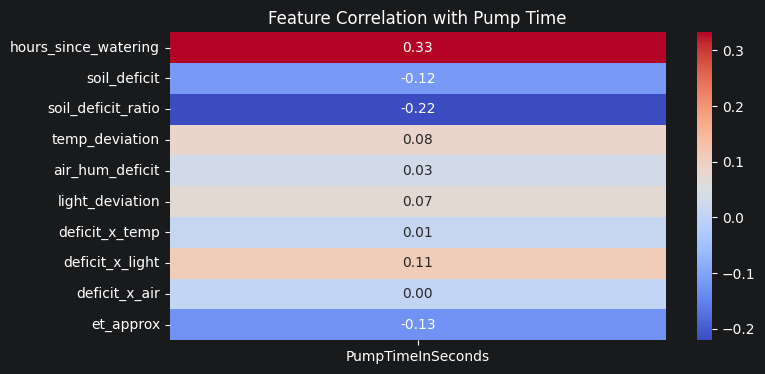

In [4]:
from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [5]:
# import xgboost as xgb
# import random
# from sklearn.metrics import mean_absolute_error
# random.seed(42)
# # convert to GPU DMatrix
# dtrain = xgb.DMatrix(X_train, label=y_train)
# dval = xgb.DMatrix(X_val, label=y_val)
# dtest = xgb.DMatrix(X_test, label=y_test)
#
# param_grid = {
#     "max_depth": [3, 9, 15],
#     "learning_rate": [0.01, 0.05, 0.2],
#     "subsample": [0.7, 1.0],
#     "colsample_bytree": [0.7, 0.85, 1.0],
#     "min_child_weight": [1, 3, 5],
#     "reg_alpha": [0, 0.1, 1, 10],
#     "reg_lambda": [0.1, 1, 10 ],
# }
#
# def sample_params():
#     return {
#         "objective": "reg:squarederror",
#         "eval_metric": "mae",
#         "tree_method": "hist",
#         "device": "cuda",
#         "max_depth": random.choice(param_grid["max_depth"]),
#         "learning_rate": random.choice(param_grid["learning_rate"]),
#         "subsample": random.choice(param_grid["subsample"]),
#         "colsample_bytree": random.choice(param_grid["colsample_bytree"]),
#         "min_child_weight": random.choice(param_grid["min_child_weight"]),
#         "reg_alpha": random.choice(param_grid["reg_alpha"]),
#         "reg_lambda": random.choice(param_grid["reg_lambda"]),
#     }
#
# best_score = float("inf")
# best_params = None
# best_model = None
# best_num_boost_round = None
# N_TRIALS = 40
#
# for i in range(N_TRIALS):
#     params = sample_params()
#
#     cv_results = xgb.cv(
#         params,
#         dtrain,
#         num_boost_round=500,
#         nfold=3,
#         early_stopping_rounds=20,
#         metrics="mae",
#         seed=42,
#         verbose_eval=False
#     )
#
#     score = cv_results["test-mae-mean"].min()
#
#     print(f"Trial {i+1}/{N_TRIALS} → MAE: {score:.4f}")
#
#     if score < best_score:
#         best_score = score
#         best_params = params
#         best_num_boost_round = len(cv_results)
#
# # train final model
# final_model = xgb.train(
#     best_params,
#     dtrain,
#     num_boost_round=best_num_boost_round,
#     evals=[(dval, "val")],
#     verbose_eval=False
# )
#
# # predictions
# preds = final_model.predict(dval)
#
# print(best_params)
# print("MAE:", mean_absolute_error(y_val, preds))

In [6]:
import xgboost as xgb
import optuna

from sklearn.metrics import mean_absolute_error

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)
def get_xgb_device():
    try:
        # tries to init CUDA, falls back if not available
        test = xgb.XGBClassifier(device="cuda", n_estimators=1)
        return "cuda"
    except Exception:
        return "cpu"

def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",

        # GPU
        "tree_method": "hist",
        "device": get_xgb_device(),

        # Hyperparameters
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # Extra useful params
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "max_bin": trial.suggest_int("max_bin", 128, 512),

        # Optional
        "seed": 42,
    }

    cv_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=2000,
        nfold=3,
        early_stopping_rounds=50,
        metrics="mae",
        seed=42,
        verbose_eval=False,
    )

    best_score = cv_results["test-mae-mean"].min()

    # save best boosting round
    trial.set_user_attr("best_num_boost_round", len(cv_results))

    return best_score


# Create study
study = optuna.create_study(
    direction="minimize",
    study_name="xgb_pump_runtime"
)

# Run optimization
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Best results
best_params = study.best_params
best_num_boost_round = study.best_trial.user_attrs["best_num_boost_round"]

print("\nBest Params:")
print(best_params)

print("\nBest CV MAE:")
print(study.best_value)

# Add required training params back
best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "device": "cuda",
    "seed": 42,
})

# Train final model
final_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=best_num_boost_round,
    evals=[(dval, "validation")],
    verbose_eval=False
)


[I 2026-05-13 12:45:21,173] A new study created in memory with name: xgb_pump_runtime


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-05-13 12:45:24,335] Trial 0 failed with parameters: {'max_depth': 7, 'learning_rate': 0.093267723873445, 'subsample': 0.9160275885944011, 'colsample_bytree': 0.7282118763868206, 'min_child_weight': 2, 'reg_alpha': 3.108706175992517, 'reg_lambda': 2.594965749894896, 'gamma': 4.257930556970256, 'max_bin': 205} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/workspace/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_14465/3295654599.py", line 41, in objective
    cv_results = xgb.cv(
                 ^^^^^^^
  File "/workspace/.venv/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/workspace/.venv/lib/python3.12/site-packages/xgboost/training.py", line 597, in cv
    booster.update(i, obj)
  File "/workspace/.venv/lib/python3.12

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluate
preds_val = final_model.predict(dval)
preds_test = final_model.predict(dtest)

print(f"\nBest params: {best_params}")
print(f"Best num_boost_round: {best_num_boost_round}")
print(f"\nVal  MAE: {mean_absolute_error(y_val, preds_val):.3f}")
print(f"Val  MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val  R²:  {r2_score(y_val, preds_val):.4f}")
print(f"\nTest MAE: {mean_absolute_error(y_test, preds_test):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")

import os
# Delete old model before training
if os.path.exists("/models/pump_time/xgb_pump_time_regretion_model.ubj"):
    os.remove("/models/pump_time/xgb_pump_time_regretion_model.ubj")
    print("Old model deleted")

final_model.save_model("/workspace/models/pump_time/xgb_pump_time_regretion_model.ubj")
print("\nModel saved.")